# Predicting Fraudulent Transactions

First we will import the data and import required libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [2]:
# Reading the dataset
df=pd.read_csv(r"C:\Users\brand\Downloads\Fraud.csv")
df.shape

(6362620, 11)

In [3]:
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Checking for Null Values
df.isnull().values.any()

False

In [5]:
# Understanding the datatype of each columns
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


After looking this we can say that column 'nameOrig' and column 'nameDest' are not necessary for predictions as it is unique id. So we are droping these two columns from our dataset.  

In [7]:
df = df.drop(df.columns[[3,6]], axis=1)
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0


In [8]:
print(df.type.unique())

['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']


<AxesSubplot:>

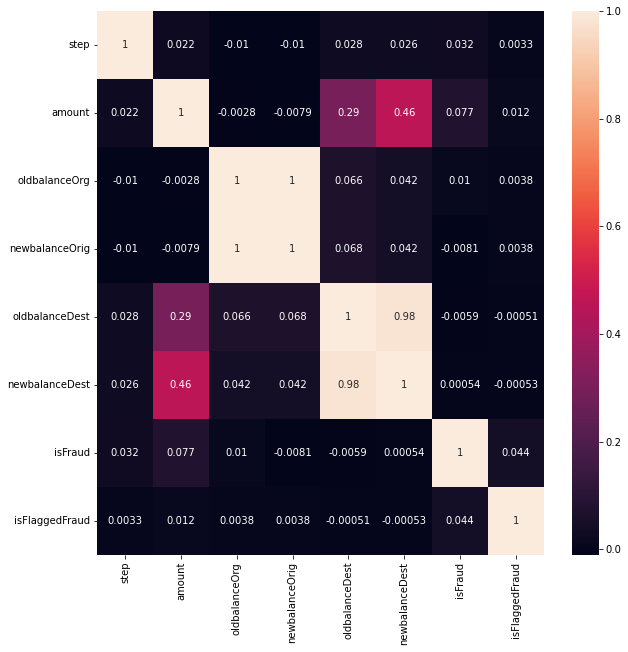

In [9]:
corr=df.corr()
plt.subplots(figsize=(10,10))
sns.heatmap(corr, annot=True)

In [10]:
# Input Variable
X = df.drop(['isFraud'], axis=1) 
X

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,0
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,0
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0
...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,0
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,0
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,0
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,0


In [11]:
# Target Variable
Y = df['isFraud'] 
Y

0          0
1          0
2          1
3          1
4          0
          ..
6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, Length: 6362620, dtype: int64

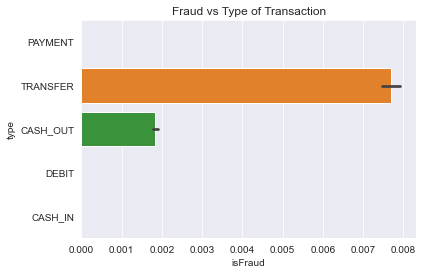

In [12]:
sns.set_style('darkgrid')
sns.barplot(x = 'isFraud', y = 'type', data = df).set(title = 'Fraud vs Type of Transaction')
plt.show()

Here We can see that Transfer method is mostly used for fraud transaction and Cash Out is on second in the list.

In [13]:
print("{}% of the data is having class 1 ".format ((len(df[df.isFraud==1])/len(df)*100)))
print("{}% of the data is having class 0 ".format ((len(df[df.isFraud==0])/len(df)*100)))

0.12908204481801522% of the data is having class 1 
99.87091795518198% of the data is having class 0 


Here we can see that approx. 0.13 % is belonging to class 1 i.e Fraud transaction and remaining in the ccategory of No Fraud transaction

In this dataset my input variable containing both numarical and categorical variables. So here we will segregate numerical and categorical variable. We will apply One-hot encoding to categorical variable and apply Normalization or Min-Max Scaling to transform features on a similar scale.

In [14]:
numerical_col = X.select_dtypes(include=np.number).columns.tolist()
categorical_col = X.select_dtypes('object').columns.tolist()

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(df[numerical_col])
MinMaxScaler(copy=True, feature_range=(0, 1))

MinMaxScaler()

In [16]:
X[numerical_col] = scaler.fit_transform(X[numerical_col])

In [17]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse=False, handle_unknown="ignore")
encoder.fit(df[categorical_col])
encoder.categories_
encoded_col = list(encoder.get_feature_names_out(categorical_col))
print(encoded_col)

['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [18]:
X[encoded_col] = encoder.transform(X[categorical_col])

In [19]:
X_new = pd.concat([X[numerical_col],X[encoded_col]],axis=1)
list(X_new)

['step',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'isFlaggedFraud',
 'type_CASH_IN',
 'type_CASH_OUT',
 'type_DEBIT',
 'type_PAYMENT',
 'type_TRANSFER']

In [20]:
from sklearn.model_selection import train_test_split
X_new_train,X_new_test,Y_train,Y_test = train_test_split(X_new,Y,test_size=0.3, stratify=Y, random_state=1)

X_new_train.shape
X_new_test.shape
Y_train.shape
Y_test.shape

(1908786,)

In [21]:
from sklearn.linear_model import LogisticRegression
LogReg = LogisticRegression(solver = 'saga', max_iter=10000)
LogReg.fit(X_new_train,Y_train)
LogReg.intercept_
LogReg.coef_

Y_pred_train = LogReg.predict(X_new_train)
Y_pred_test = LogReg.predict(X_new_test)

In [22]:
from sklearn.metrics import confusion_matrix,accuracy_score
CM = confusion_matrix(Y_test,Y_pred_test)
CM



array([[1906305,      17],
       [   2253,     211]], dtype=int64)

In [27]:
Accuracy_Score = accuracy_score(Y_test,Y_pred_test)
print("Accuracy score of logistic model is {} % ".format ((Accuracy_Score.round(6)*100)))

Accuracy score of logistic model is 99.8811 % 
